# RSNN on PTB-XL ECG — Extended Experiments

**Carried-forward results** (from iter-3-4):
| Model | Test Accuracy |
|---|---|
| RSNN Direct Input | 61.24% |
| RSNN Rate Coding | 50.19% |
| RSNN Temporal Contrast | 61.05% |
| RSNN Delta Modulation | **63.23%** |
| LSTM (2L, 128) | 67.07% |
| 1D-CNN | 66.28% |

**Split**: Strodthoff et al. 2020 — folds 1-8 train, fold 9 val, fold 10 test.
Early stopping on validation accuracy.

**This notebook adds**:
- E1-E3: Architecture experiments (hidden size, depth, time constants)
- E4-E8: Analysis suite (readout comparison, early classification, noise, efficiency, ablation)
- E9-E11: ECG-specific (lead ablation, reduced-lead, class-wise temporal)

**Datasets**: Add 'ptb-xl-dataset' by khyeh0719 to Kaggle notebook.

## 0. Setup

In [1]:
import sys, subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'snntorch', 'wfdb', '-q'])
print('Done.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 8.3 MB/s eta 0:00:00


Done.


In [2]:
import os, glob, copy, time, json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name()}')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

SAVE_DIR = '/kaggle/working'
RESULTS = {}

Device: cuda
GPU: Tesla T4


## 1. Spike Encoding

In [3]:
class SpikeEncoder:
    @staticmethod
    def direct(signal):
        return signal

    @staticmethod
    def rate_coding(signal):
        sig_min = signal.min(axis=0, keepdims=True)
        sig_max = signal.max(axis=0, keepdims=True)
        probs = (signal - sig_min) / (sig_max - sig_min + 1e-8)
        return (np.random.rand(*signal.shape) < probs).astype(np.float32)

    @staticmethod
    def delta_modulation(signal, threshold=0.1):
        T, C = signal.shape
        spikes = np.zeros_like(signal)
        reference = signal[0].copy()
        for t in range(1, T):
            diff = signal[t] - reference
            up = diff > threshold
            down = diff < -threshold
            spikes[t, up] = 1.0
            spikes[t, down] = -1.0
            reference[up] = signal[t, up]
            reference[down] = signal[t, down]
        return spikes

    @staticmethod
    def temporal_contrast(signal, threshold=0.05):
        T, C = signal.shape
        spikes = np.zeros((T, C * 2), dtype=np.float32)
        for t in range(1, T):
            diff = signal[t] - signal[t - 1]
            spikes[t, :C] = (diff > threshold).astype(np.float32)
            spikes[t, C:] = (diff < -threshold).astype(np.float32)
        return spikes

## 2. SNN Components

Identical to SHD implementation. Surrogate gradient (Cramer et al. 2020 Eq. 8),
LIF layer with recurrent dropout, leaky membrane readout.

In [4]:
class SurrogateSpike(torch.autograd.Function):
    beta = 40.0
    @staticmethod
    def forward(ctx, mem, threshold=1.0):
        ctx.save_for_backward(mem)
        ctx.threshold = threshold
        return (mem >= threshold).float()
    @staticmethod
    def backward(ctx, grad_output):
        mem, = ctx.saved_tensors
        v = mem - ctx.threshold
        grad = 1.0 / (1.0 + SurrogateSpike.beta * torch.abs(v)) ** 2
        return grad_output * grad, None

def spike_fn(x, threshold=1.0):
    return SurrogateSpike.apply(x, threshold)

In [5]:
class LIFLayer(nn.Module):
    def __init__(self, input_size, hidden_size, recurrent=False,
                 tau_mem_init=20.0, tau_syn_init=10.0, dt=10.0,
                 learnable_tau=False, dropout=0.0):
        super().__init__()
        self.hidden_size = hidden_size
        self.recurrent = recurrent
        self.dt = dt
        self.dropout = dropout
        self.W_ff = nn.Linear(input_size, hidden_size, bias=False)
        if recurrent:
            self.W_rec = nn.Linear(hidden_size, hidden_size, bias=False)
        if learnable_tau:
            self.log_tau_mem = nn.Parameter(torch.tensor(np.log(tau_mem_init)))
            self.log_tau_syn = nn.Parameter(torch.tensor(np.log(tau_syn_init)))
        else:
            self.register_buffer('log_tau_mem', torch.tensor(np.log(tau_mem_init)))
            self.register_buffer('log_tau_syn', torch.tensor(np.log(tau_syn_init)))
        nn.init.kaiming_uniform_(self.W_ff.weight, nonlinearity='linear')
        if recurrent:
            nn.init.kaiming_uniform_(self.W_rec.weight, nonlinearity='linear')

    @property
    def alpha(self):
        return torch.exp(-self.dt / torch.exp(self.log_tau_syn))
    @property
    def beta(self):
        return torch.exp(-self.dt / torch.exp(self.log_tau_mem))

    def forward(self, x):
        B, T, _ = x.shape
        alpha, beta = self.alpha, self.beta
        syn = torch.zeros(B, self.hidden_size, device=x.device)
        mem = torch.zeros(B, self.hidden_size, device=x.device)
        prev_spk = torch.zeros(B, self.hidden_size, device=x.device)
        spike_rec, mem_rec = [], []
        for t in range(T):
            syn = alpha * syn + self.W_ff(x[:, t])
            if self.recurrent:
                rec_spk = F.dropout(prev_spk, p=self.dropout,
                                    training=self.training) if self.dropout > 0 else prev_spk
                syn = syn + self.W_rec(rec_spk)
            mem = beta * mem * (1.0 - prev_spk) + (1.0 - beta) * syn
            spk = spike_fn(mem, threshold=1.0)
            spike_rec.append(spk)
            mem_rec.append(mem)
            prev_spk = spk
        return torch.stack(spike_rec, dim=1), torch.stack(mem_rec, dim=1)

In [6]:
class ReadoutLayer(nn.Module):
    def __init__(self, input_size, output_size, tau_mem=20.0, dt=10.0):
        super().__init__()
        self.fc = nn.Linear(input_size, output_size, bias=False)
        self.beta = np.exp(-dt / tau_mem)
        nn.init.kaiming_uniform_(self.fc.weight, nonlinearity='linear')
    def forward(self, x):
        B, T, _ = x.shape
        mem = torch.zeros(B, self.fc.out_features, device=x.device)
        mem_rec = []
        for t in range(T):
            mem = self.beta * mem + (1.0 - self.beta) * self.fc(x[:, t])
            mem_rec.append(mem)
        return torch.stack(mem_rec, dim=1)


class SNN(nn.Module):
    def __init__(self, input_size, hidden_size=256, output_size=5,
                 n_hidden_layers=1, recurrent=True,
                 tau_mem=20.0, tau_syn=10.0, dt=10.0,
                 learnable_tau=False, loss_mode='max_over_time',
                 dropout=0.0):
        super().__init__()
        self.loss_mode = loss_mode
        self.hidden_size = hidden_size
        layers = []
        for i in range(n_hidden_layers):
            in_sz = input_size if i == 0 else hidden_size
            layers.append(LIFLayer(in_sz, hidden_size, recurrent=recurrent,
                tau_mem_init=tau_mem, tau_syn_init=tau_syn, dt=dt,
                learnable_tau=learnable_tau, dropout=dropout))
        self.hidden_layers = nn.ModuleList(layers)
        self.readout = ReadoutLayer(hidden_size, output_size, tau_mem=tau_mem, dt=dt)

    def forward(self, x):
        all_spikes = []
        h = x
        for layer in self.hidden_layers:
            spikes, _ = layer(h)
            all_spikes.append(spikes)
            h = spikes
        out_mem = self.readout(h)
        if self.loss_mode == 'max_over_time':
            output, _ = torch.max(out_mem, dim=1)
        elif self.loss_mode == 'last_timestep':
            output = out_mem[:, -1, :]
        else:
            raise ValueError(f'Unknown loss_mode: {self.loss_mode}')
        return output, all_spikes, out_mem

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [7]:
class LSTMBaseline(nn.Module):
    def __init__(self, input_size, hidden_size=128, n_layers=2,
                 output_size=5, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, n_layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])
    def forward_seq(self, x):
        out, _ = self.lstm(x)
        return out
    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

class CNNBaseline(nn.Module):
    def __init__(self, input_channels, output_size=5):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_channels, 64, 5, padding=2), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 5, padding=2), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128, 128, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Linear(128, output_size)
    def forward(self, x):
        h = self.conv(x.transpose(1, 2))
        return self.fc(h.squeeze(-1))
    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

## 3. Training Engine

Early stopping on **validation** accuracy (fold 9). Test set (fold 10) evaluated
but never used for model selection. Matches Strodthoff et al. 2020 protocol.

In [8]:
def spike_regularization(all_spikes, theta_l=0.01, s_l=1.0, theta_u=100.0, s_u=0.06):
    reg = torch.tensor(0.0, device=all_spikes[0].device)
    for spk in all_spikes:
        B, T, N = spk.shape
        mean_rate = spk.sum(dim=1) / T
        reg += s_l / (B * N) * (F.relu(theta_l - mean_rate) ** 2).sum()
        pop_count = spk.sum(dim=(1, 2)) / N
        reg += s_u / B * (F.relu(pop_count - theta_u) ** 2).sum()
    return reg


def train_snn(model, train_ld, val_ld, test_ld, n_epochs=100, lr=1e-3,
              device='cuda', patience=20, verbose_every=10):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    best_val, best_state, wait = 0, None, 0
    t0 = time.time()
    for epoch in range(n_epochs):
        model.train()
        tot_loss, correct, total = 0, 0, 0
        for x, y in train_ld:
            x, y = x.to(device), y.to(device)
            logits, spks, _ = model(x)
            loss = criterion(logits, y)
            if spks:
                loss += spike_regularization(spks)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tot_loss += loss.item() * len(y)
            correct += (logits.argmax(1) == y).sum().item()
            total += len(y)
        train_acc = correct / total
        val_acc = _eval(model, val_ld, device)
        test_acc = _eval(model, test_ld, device)
        if val_acc > best_val:
            best_val = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
        if epoch % verbose_every == 0 or epoch == n_epochs - 1:
            m = '*' if wait == 0 else ''
            print(f'  Ep {epoch:3d}: loss={tot_loss/total:.4f} tr={train_acc:.4f} '
                  f'va={val_acc:.4f} te={test_acc:.4f} {m}')
        if wait >= patience:
            print(f'  Early stop at epoch {epoch}')
            break
    if best_state:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    final = _eval(model, test_ld, device)
    print(f'  Final test (best-val checkpoint): {final*100:.2f}% ({time.time()-t0:.0f}s)')
    return final, model


@torch.no_grad()
def _eval(model, loader, device, is_snn=True):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if is_snn:
            logits, _, _ = model(x)
        else:
            logits = model(x)
        correct += (logits.argmax(1) == y).sum().item()
        total += len(y)
    return correct / total


def train_baseline(model, train_ld, val_ld, test_ld, n_epochs=80, lr=1e-3,
                   device='cuda', patience=20):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    best_val, best_state, wait = 0, None, 0
    t0 = time.time()
    for epoch in range(n_epochs):
        model.train()
        for x, y in train_ld:
            x, y = x.to(device), y.to(device)
            loss = criterion(model(x), y)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        val_acc = _eval(model, val_ld, device, is_snn=False)
        if val_acc > best_val:
            best_val = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
        if epoch % 20 == 0:
            te = _eval(model, test_ld, device, is_snn=False)
            print(f'  Ep {epoch}: val={val_acc:.4f} test={te:.4f}')
        if wait >= patience:
            print(f'  Early stop at epoch {epoch}'); break
    if best_state:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    final = _eval(model, test_ld, device, is_snn=False)
    print(f'  Final: {final*100:.2f}% ({time.time()-t0:.0f}s)')
    return final, model

## 4. Load PTB-XL Data

Strodthoff et al. 2020 standard split: folds 1-8 train, fold 9 val, fold 10 test.

In [9]:
import wfdb, ast, pandas as pd

ecg_csv = glob.glob('/kaggle/input/**/ptbxl_database.csv', recursive=True)
assert ecg_csv, 'ptbxl_database.csv not found'
ECG_DIR = os.path.dirname(ecg_csv[0])
print(f'ECG_DIR: {ECG_DIR}')

df = pd.read_csv(os.path.join(ECG_DIR, 'ptbxl_database.csv'))
df.scp_codes = df.scp_codes.apply(ast.literal_eval)
scp_df = pd.read_csv(os.path.join(ECG_DIR, 'scp_statements.csv'), index_col=0)
scp_df = scp_df[scp_df.diagnostic == 1.0]

SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
c2i = {c: i for i, c in enumerate(SUPERCLASSES)}
N_CLASSES = 5

def get_sc(scp):
    best, lk = None, 0
    for k, v in scp.items():
        if k in scp_df.index:
            sc = scp_df.loc[k].diagnostic_class
            if sc in SUPERCLASSES and v > lk:
                best, lk = sc, v
    return best

df['sc'] = df.scp_codes.apply(get_sc)
df = df.dropna(subset=['sc'])
df['label'] = df.sc.map(c2i)

# Standard split
df_train = df[df.strat_fold <= 8]
df_val = df[df.strat_fold == 9]
df_test = df[df.strat_fold == 10]
print(f'Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')

def load_ecg(df_sub):
    sigs, labs = [], []
    for _, r in df_sub.iterrows():
        try:
            p = os.path.join(ECG_DIR, r['filename_lr'])
            if p.endswith('.hea'): p = p[:-4]
            sigs.append(wfdb.rdrecord(p).p_signal.astype(np.float32))
            labs.append(r['label'])
        except: pass
    return np.array(sigs), np.array(labs)

print('Loading ECG waveforms...')
X_tr, y_tr = load_ecg(df_train)
X_va, y_va = load_ecg(df_val)
X_te, y_te = load_ecg(df_test)

# Per-channel normalisation (fit on train only)
mu = X_tr.mean(axis=(0, 1))
sd = X_tr.std(axis=(0, 1)) + 1e-8
X_tr = (X_tr - mu) / sd
X_va = (X_va - mu) / sd
X_te = (X_te - mu) / sd
print(f'X_tr: {X_tr.shape}, X_va: {X_va.shape}, X_te: {X_te.shape}')

ECG_DIR: /kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1


Train: 17100 | Val: 2155 | Test: 2162
Loading ECG waveforms...


X_tr: (17100, 1000, 12), X_va: (2155, 1000, 12), X_te: (2162, 1000, 12)


In [10]:
class ECGDataset(Dataset):
    def __init__(self, X, y, encoding='delta', n_time_bins=250, **kw):
        self.X, self.y = X, torch.tensor(y, dtype=torch.long)
        self.encoding, self.n_bins, self.kw = encoding, n_time_bins, kw
        self.input_size = self._enc(X[0]).shape[1]
    def _enc(self, sig):
        idx = np.linspace(0, sig.shape[0] - 1, self.n_bins).astype(int)
        s = sig[idx]
        if self.encoding == 'direct': return s
        elif self.encoding == 'delta': return SpikeEncoder.delta_modulation(s, **self.kw)
        elif self.encoding == 'tc': return SpikeEncoder.temporal_contrast(s, **self.kw)
        elif self.encoding == 'rate': return SpikeEncoder.rate_coding(s)
        return s
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return torch.tensor(self._enc(self.X[i]), dtype=torch.float32), self.y[i]

N_BINS = 250
BS = 128

# Delta mod loaders (best encoding)
ds_tr = ECGDataset(X_tr, y_tr, 'delta', N_BINS, threshold=0.1)
ds_va = ECGDataset(X_va, y_va, 'delta', N_BINS, threshold=0.1)
ds_te = ECGDataset(X_te, y_te, 'delta', N_BINS, threshold=0.1)
train_ld = DataLoader(ds_tr, BS, True, num_workers=2)
val_ld = DataLoader(ds_va, BS, False, num_workers=2)
test_ld = DataLoader(ds_te, BS, False, num_workers=2)

# Direct loaders (for LSTM/CNN)
ds_tr_d = ECGDataset(X_tr, y_tr, 'direct', N_BINS)
ds_va_d = ECGDataset(X_va, y_va, 'direct', N_BINS)
ds_te_d = ECGDataset(X_te, y_te, 'direct', N_BINS)
train_ld_d = DataLoader(ds_tr_d, BS, True, num_workers=2)
val_ld_d = DataLoader(ds_va_d, BS, False, num_workers=2)
test_ld_d = DataLoader(ds_te_d, BS, False, num_workers=2)

INPUT_SIZE = ds_tr.input_size  # 12 for delta mod
print(f'Input size: {INPUT_SIZE}, Timesteps: {N_BINS}, Classes: {N_CLASSES}')

Input size: 12, Timesteps: 250, Classes: 5


## 5. Baselines: LSTM and CNN

Retrain here to have models available for all analysis experiments.

In [11]:
print('--- LSTM ---')
model_lstm = LSTMBaseline(12, 128, 2, N_CLASSES, 0.3)
acc_lstm, model_lstm = train_baseline(model_lstm, train_ld_d, val_ld_d, test_ld_d)
RESULTS['LSTM'] = acc_lstm

print('\n--- CNN ---')
model_cnn = CNNBaseline(12, N_CLASSES)
acc_cnn, model_cnn = train_baseline(model_cnn, train_ld_d, val_ld_d, test_ld_d)
RESULTS['CNN'] = acc_cnn

--- LSTM ---


  Ep 0: val=0.5007 test=0.5000


  Ep 20: val=0.6246 test=0.6138


  Ep 40: val=0.6617 test=0.6660


  Ep 60: val=0.6789 test=0.6711


  Final: 66.70% (280s)

--- CNN ---


  Ep 0: val=0.6376 test=0.6411


  Ep 20: val=0.7067 test=0.7165


  Early stop at epoch 36


  Final: 70.31% (48s)


## 6. Base RSNN (Delta Modulation)

Reproduces the iter-3-4 result. 256 hidden, 1 layer, recurrent, learnable tau.

In [12]:
print('--- RSNN Delta Mod (base) ---')
model_base = SNN(INPUT_SIZE, hidden_size=256, output_size=N_CLASSES,
    n_hidden_layers=1, recurrent=True, tau_mem=20.0, tau_syn=10.0,
    dt=10.0, learnable_tau=True, loss_mode='max_over_time', dropout=0.3)
print(f'Params: {model_base.count_params():,}')
acc_base, model_base = train_snn(model_base, train_ld, val_ld, test_ld)
RESULTS['RSNN_base'] = acc_base
torch.save(model_base.state_dict(), os.path.join(SAVE_DIR, 'rsnn_base_ecg.pth'))

--- RSNN Delta Mod (base) ---
Params: 69,890


  Ep   0: loss=1.3088 tr=0.4911 va=0.5401 te=0.5282 *


  Ep  10: loss=0.9997 tr=0.6298 va=0.6005 te=0.5971 


  Ep  20: loss=0.9796 tr=0.6389 va=0.6107 te=0.6203 


  Ep  30: loss=0.9560 tr=0.6482 va=0.6246 te=0.6221 


  Ep  40: loss=0.9547 tr=0.6510 va=0.6274 te=0.6152 


  Ep  50: loss=0.9548 tr=0.6461 va=0.6158 te=0.6318 


  Ep  60: loss=0.9461 tr=0.6501 va=0.6144 te=0.6272 


  Early stop at epoch 61


  Final test (best-val checkpoint): 62.49% (4111s)


## 7. Exp E1: Hidden Size Sweep

128 vs 256 vs 512 neurons. ECG has only 12 input channels (vs 700 SHD),
so the optimal hidden size may be smaller.

In [13]:
print('='*60)
print('E1: HIDDEN SIZE SWEEP')
print('='*60)

for hs in [128, 512]:
    print(f'\n--- hidden_size={hs} ---')
    m = SNN(INPUT_SIZE, hidden_size=hs, output_size=N_CLASSES,
        n_hidden_layers=1, recurrent=True, tau_mem=20.0, tau_syn=10.0,
        dt=10.0, learnable_tau=True, loss_mode='max_over_time', dropout=0.3)
    print(f'Params: {m.count_params():,}')
    acc, m = train_snn(m, train_ld, val_ld, test_ld)
    RESULTS[f'RSNN_h{hs}'] = acc
    torch.save(m.state_dict(), os.path.join(SAVE_DIR, f'rsnn_h{hs}_ecg.pth'))

print(f'\nHidden size results: 128={RESULTS.get("RSNN_h128",0)*100:.2f}%, '
      f'256={acc_base*100:.2f}%, 512={RESULTS.get("RSNN_h512",0)*100:.2f}%')

E1: HIDDEN SIZE SWEEP

--- hidden_size=128 ---
Params: 18,562


  Ep   0: loss=1.3659 tr=0.4586 va=0.5021 te=0.5079 *


  Ep  10: loss=1.0277 tr=0.6151 va=0.5968 te=0.5948 *


  Ep  20: loss=1.0021 tr=0.6242 va=0.6056 te=0.5990 *


  Ep  30: loss=0.9893 tr=0.6309 va=0.6028 te=0.6078 


...

  Ep  20: loss=1.0566 tr=0.6055 va=0.5800 te=0.5883 


  Ep  30: loss=1.0507 tr=0.6064 va=0.5694 te=0.5726 


  Ep  40: loss=1.0706 tr=0.6009 va=0.5745 te=0.5726 


  Early stop at epoch 46


  Final test (best-val checkpoint): 60.45% (3966s)

Hidden size results: 128=61.47%, 256=62.49%, 512=60.45%


## 8. Exp E2: Depth (2 Hidden Layers)

ECG has hierarchical temporal features (P-QRS-T). A second layer
might capture higher-order patterns. Cramer et al. 2020 Fig 8b.

In [14]:
print('='*60)
print('E2: 2-LAYER RSNN')
print('='*60)

model_2l = SNN(INPUT_SIZE, hidden_size=256, output_size=N_CLASSES,
    n_hidden_layers=2, recurrent=True, tau_mem=20.0, tau_syn=10.0,
    dt=10.0, learnable_tau=True, loss_mode='max_over_time', dropout=0.3)
print(f'Params: {model_2l.count_params():,}')
acc_2l, model_2l = train_snn(model_2l, train_ld, val_ld, test_ld)
RESULTS['RSNN_2layer'] = acc_2l

E2: 2-LAYER RSNN
Params: 200,964


  Ep   0: loss=1.3344 tr=0.4944 va=0.5638 te=0.5449 *


  Ep  10: loss=0.9582 tr=0.6489 va=0.6302 te=0.6327 *


  Ep  20: loss=0.9351 tr=0.6577 va=0.6200 te=0.6337 


  Ep  30: loss=0.9316 tr=0.6606 va=0.6334 te=0.6332 


...

  Ep  50: loss=0.9120 tr=0.6647 va=0.6362 te=0.6392 


  Ep  60: loss=0.9116 tr=0.6643 va=0.6339 te=0.6471 


  Ep  70: loss=0.9100 tr=0.6662 va=0.6353 te=0.6475 


  Early stop at epoch 72


  Final test (best-val checkpoint): 65.26% (7596s)


## 9. Exp E3: Time Constant Sweep

ECG features span multiple timescales: QRS ~100ms, T-wave ~300ms,
full beat ~800ms. Base tau_mem=20ms (effective memory ~60ms at dt=10ms)
may be too short for T-wave features.

Sweep tau_mem in {10, 40, 80, 160}ms (20ms is the base, already run).

In [15]:
print('='*60)
print('E3: TIME CONSTANT SWEEP')
print('='*60)

for tau in [10.0, 40.0, 80.0, 160.0]:
    print(f'\n--- tau_mem={tau}ms ---')
    m = SNN(INPUT_SIZE, hidden_size=256, output_size=N_CLASSES,
        n_hidden_layers=1, recurrent=True, tau_mem=tau, tau_syn=tau/2,
        dt=10.0, learnable_tau=True, loss_mode='max_over_time', dropout=0.3)
    acc, m = train_snn(m, train_ld, val_ld, test_ld)
    RESULTS[f'RSNN_tau{int(tau)}'] = acc

print('\nTime constant results:')
for k, v in sorted(RESULTS.items()):
    if 'tau' in k:
        print(f'  {k}: {v*100:.2f}%')

E3: TIME CONSTANT SWEEP

--- tau_mem=10.0ms ---


  Ep   0: loss=1.2528 tr=0.5158 va=0.5401 te=0.5365 *


  Ep  10: loss=1.0015 tr=0.6235 va=0.5977 te=0.6105 


  Ep  20: loss=0.9944 tr=0.6320 va=0.6148 te=0.6055 


  Ep  30: loss=0.9716 tr=0.6384 va=0.6032 te=0.6082 


...

  Ep  70: loss=1.0372 tr=0.5997 va=0.5968 te=0.5953 *


  Ep  80: loss=1.0162 tr=0.6137 va=0.5930 te=0.6105 


  Ep  90: loss=0.9934 tr=0.6266 va=0.5912 te=0.5907 


  Ep  99: loss=0.9669 tr=0.6371 va=0.6172 te=0.6253 *


  Final test (best-val checkpoint): 62.53% (6563s)

Time constant results:
  RSNN_tau10: 62.35%
  RSNN_tau160: 62.53%
  RSNN_tau40: 64.01%
  RSNN_tau80: 65.03%


## 10. Exp E4: Readout Comparison

Running-max vs instantaneous readout. Tests whether temporal
efficiency finding holds on continuous ECG data.

E4: READOUT COMPARISON


RSNN t90: step 33 = 1320ms
LSTM t90: step 110 = 4400ms


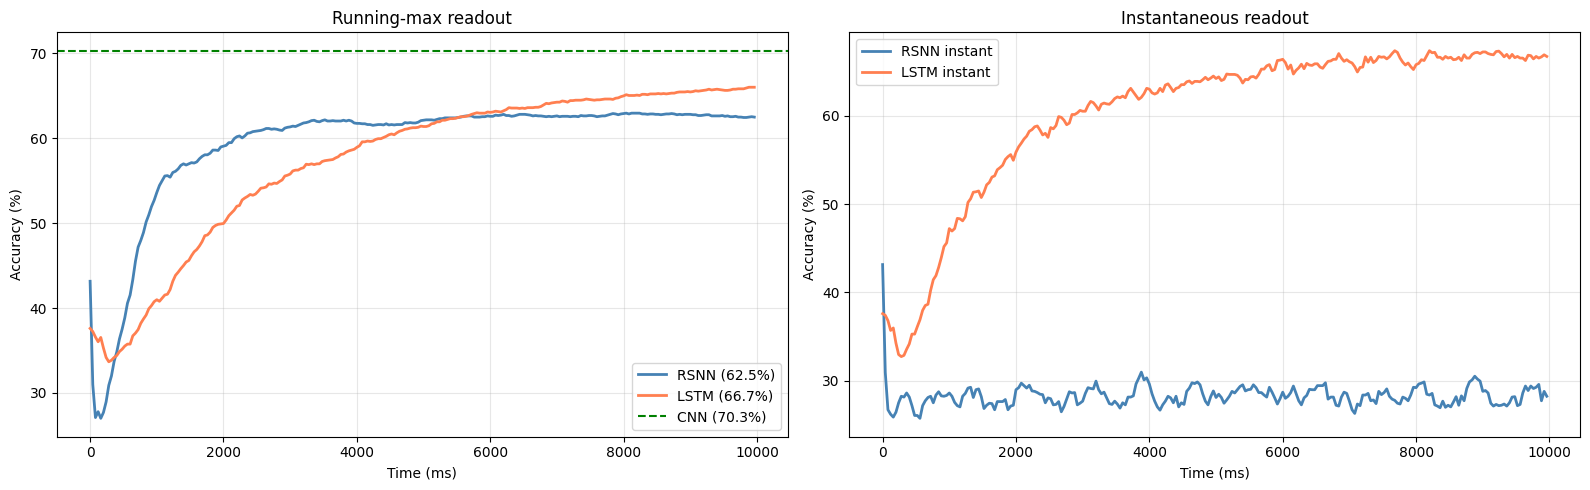

In [16]:
@torch.no_grad()
def temporal_rsnn(model, loader, device):
    model.eval()
    all_c = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        _, _, om = model(x)
        B, T, C = om.shape
        rmax = torch.full((B, C), -float('inf'), device=device)
        ct = torch.zeros(T, device=device)
        for t in range(T):
            rmax = torch.max(rmax, om[:, t])
            ct[t] += (rmax.argmax(1) == y).float().sum()
        all_c.append(ct)
    total = torch.stack(all_c).sum(0)
    n = sum(len(y) for _, y in loader)
    return (total / n).cpu().numpy()

@torch.no_grad()
def temporal_lstm(model, loader, device):
    model.eval()
    all_c = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        hseq = model.forward_seq(x)
        lseq = model.fc(hseq)
        B, T, C = lseq.shape
        rmax = torch.full((B, C), -float('inf'), device=device)
        ct = torch.zeros(T, device=device)
        for t in range(T):
            rmax = torch.max(rmax, lseq[:, t])
            ct[t] += (rmax.argmax(1) == y).float().sum()
        all_c.append(ct)
    total = torch.stack(all_c).sum(0)
    n = sum(len(y) for _, y in loader)
    return (total / n).cpu().numpy()

@torch.no_grad()
def temporal_instant(model, loader, device, is_lstm=False):
    model.eval()
    all_c = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if is_lstm:
            seq = model.fc(model.forward_seq(x))
        else:
            _, _, seq = model(x)
        B, T, C = seq.shape
        ct = torch.zeros(T, device=device)
        for t in range(T):
            ct[t] += (seq[:, t].argmax(1) == y).float().sum()
        all_c.append(ct)
    total = torch.stack(all_c).sum(0)
    n = sum(len(y) for _, y in loader)
    return (total / n).cpu().numpy()

def t_to_frac(arr, ceiling, frac):
    target = frac * ceiling
    if arr.max() < target: return None
    return int(np.argmax(arr >= target))

print('='*60)
print('E4: READOUT COMPARISON')
print('='*60)

rsnn_rm = temporal_rsnn(model_base, test_ld, device)
lstm_rm = temporal_lstm(model_lstm, test_ld_d, device)
rsnn_inst = temporal_instant(model_base, test_ld, device, False)
lstm_inst = temporal_instant(model_lstm, test_ld_d, device, True)

# 10 seconds / 250 steps = 40ms per step
dt_ms = 40
t90_r = t_to_frac(rsnn_rm, acc_base, 0.9)
t90_l = t_to_frac(lstm_rm, acc_lstm, 0.9)
print(f'RSNN t90: step {t90_r} = {t90_r*dt_ms if t90_r else "N/A"}ms')
print(f'LSTM t90: step {t90_l} = {t90_l*dt_ms if t90_l else "N/A"}ms')

time_ms = np.arange(N_BINS) * dt_ms
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(time_ms, rsnn_rm*100, lw=2, color='steelblue', label=f'RSNN ({acc_base*100:.1f}%)')
axes[0].plot(time_ms, lstm_rm*100, lw=2, color='coral', label=f'LSTM ({acc_lstm*100:.1f}%)')
axes[0].axhline(y=acc_cnn*100, color='green', ls='--', lw=1.5, label=f'CNN ({acc_cnn*100:.1f}%)')
axes[0].set_xlabel('Time (ms)'); axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Running-max readout'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(time_ms, rsnn_inst*100, lw=2, color='steelblue', label='RSNN instant')
axes[1].plot(time_ms, lstm_inst*100, lw=2, color='coral', label='LSTM instant')
axes[1].set_xlabel('Time (ms)'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Instantaneous readout'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(SAVE_DIR, 'ecg_temporal.png'), dpi=150); plt.show()

## 11. Exp E5: Per-Sample Early Classification

Per-superclass first-correct timestep. Hypothesis: MI (localised ST changes)
is classified earlier than NORM (features distributed throughout).

In [17]:
@torch.no_grad()
def early_class(model, loader, device, is_lstm=False):
    model.eval()
    all_fc, all_lab = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        B = x.shape[0]
        if is_lstm:
            lseq = model.fc(model.forward_seq(x))
        else:
            _, _, lseq = model(x)
        _, T, C = lseq.shape
        rmax = torch.full((B, C), -float('inf'), device=device)
        fc = torch.full((B,), -1, dtype=torch.long, device=device)
        for t in range(T):
            rmax = torch.max(rmax, lseq[:, t])
            newly = (rmax.argmax(1) == y) & (fc == -1)
            fc[newly] = t
        all_fc.append(fc.cpu()); all_lab.append(y.cpu())
    return torch.cat(all_fc).numpy(), torch.cat(all_lab).numpy()

print('='*60)
print('E5: EARLY CLASSIFICATION')
print('='*60)

rfc, labels = early_class(model_base, test_ld, device, False)
lfc, _ = early_class(model_lstm, test_ld_d, device, True)

print(f'{"Class":>8} {"RSNN med":>10} {"LSTM med":>10} {"Faster":>8}')
print('-'*40)
for c in range(N_CLASSES):
    m = labels == c
    rv = rfc[m][rfc[m]>=0]; lv = lfc[m][lfc[m]>=0]
    rm = np.median(rv)*dt_ms if len(rv)>0 else float('inf')
    lm = np.median(lv)*dt_ms if len(lv)>0 else float('inf')
    f = 'RSNN' if rm<lm else ('LSTM' if lm<rm else 'tie')
    print(f'  {SUPERCLASSES[c]:>6} {rm:>8.0f}ms {lm:>8.0f}ms {f:>6}')

both = (rfc>=0) & (lfc>=0)
print(f'\nMutually correct ({both.sum()}): '
      f'RSNN first {(rfc[both]<lfc[both]).sum()}, '
      f'LSTM first {(lfc[both]<rfc[both]).sum()}')

E5: EARLY CLASSIFICATION


   Class   RSNN med   LSTM med   Faster
----------------------------------------
    NORM        0ms        0ms    tie
      MI       80ms      160ms   RSNN
    STTC      320ms      840ms   RSNN
      CD      280ms      320ms   RSNN
     HYP      160ms     1340ms   RSNN

Mutually correct (1655): RSNN first 640, LSTM first 265


## 12. Exp E6: Noise Robustness

Gaussian noise sweep. ECG-specific: electrode noise, motion artifacts.
If RSNN degrades more gracefully, relevant for ambulatory monitoring.

E6: NOISE ROBUSTNESS
   Sigma       RSNN       LSTM        Gap
----------------------------------------


    0.00       62.5%      66.7%      -4.2pp


    0.05       62.6%      67.0%      -4.4pp


    0.10       63.0%      66.9%      -3.9pp


    0.20       62.7%      66.6%      -3.9pp


    0.50       58.2%      65.2%      -6.9pp


    1.00       28.4%      50.8%     -22.5pp


    2.00       18.4%      23.4%      -5.0pp


    5.00       19.1%      14.8%      +4.3pp


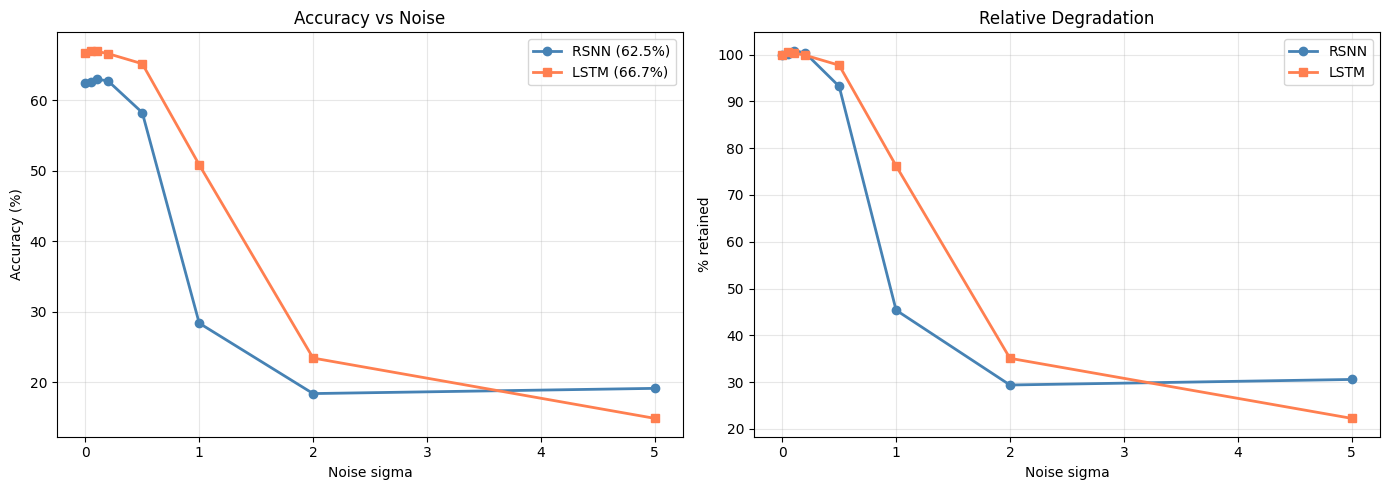

In [18]:
@torch.no_grad()
def eval_noise(model, loader, device, sigma, is_snn=True):
    model.eval()
    c, t = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        xn = x + sigma * torch.randn_like(x)
        if is_snn: logits, _, _ = model(xn)
        else: logits = model(xn)
        c += (logits.argmax(1)==y).sum().item(); t += len(y)
    return c/t

print('='*60)
print('E6: NOISE ROBUSTNESS')
print('='*60)

sigmas = [0, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0]
rsnn_noise, lstm_noise = [], []
print(f'{"Sigma":>8} {"RSNN":>10} {"LSTM":>10} {"Gap":>10}')
print('-'*40)
for s in sigmas:
    r = eval_noise(model_base, test_ld, device, s, True)
    l = eval_noise(model_lstm, test_ld_d, device, s, False)
    rsnn_noise.append(r); lstm_noise.append(l)
    print(f'  {s:>6.2f}   {r*100:>8.1f}%  {l*100:>8.1f}%  {(r-l)*100:>+8.1f}pp')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(sigmas, [a*100 for a in rsnn_noise], 'o-', color='steelblue', lw=2, label=f'RSNN ({acc_base*100:.1f}%)')
axes[0].plot(sigmas, [a*100 for a in lstm_noise], 's-', color='coral', lw=2, label=f'LSTM ({acc_lstm*100:.1f}%)')
axes[0].set_xlabel('Noise sigma'); axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy vs Noise'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
rr = [a/rsnn_noise[0]*100 for a in rsnn_noise]
lr = [a/lstm_noise[0]*100 for a in lstm_noise]
axes[1].plot(sigmas, rr, 'o-', color='steelblue', lw=2, label='RSNN')
axes[1].plot(sigmas, lr, 's-', color='coral', lw=2, label='LSTM')
axes[1].set_xlabel('Noise sigma'); axes[1].set_ylabel('% retained')
axes[1].set_title('Relative Degradation'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(SAVE_DIR, 'ecg_noise.png'), dpi=150); plt.show()

## 13. Exp E7: Spike Efficiency

In [19]:
@torch.no_grad()
def count_spikes(model, loader, device):
    model.eval()
    counts = []
    for x, y in loader:
        x = x.to(device)
        _, spks, _ = model(x)
        batch_total = sum(s.sum(dim=(1,2)).cpu().numpy() for s in spks)
        counts.append(batch_total)
    return np.concatenate(counts)

print('='*60)
print('E7: SPIKE EFFICIENCY')
print('='*60)

sc = count_spikes(model_base, test_ld, device)
rsnn_ops = sc.mean() * (256 + N_CLASSES)
lstm_l1 = 4 * (12*128 + 128*128)
lstm_l2 = 4 * (128*128 + 128*128)
lstm_ops = (lstm_l1 + lstm_l2) * N_BINS

print(f'RSNN: mean {sc.mean():.0f} spikes, {rsnn_ops:,.0f} ops')
print(f'LSTM: {lstm_ops:,.0f} ops ({lstm_ops/max(rsnn_ops,1):.1f}x more)')
print(f'Accuracy per M-ops: RSNN={acc_base*100/(rsnn_ops/1e6):.2f}, LSTM={acc_lstm*100/(lstm_ops/1e6):.2f}')

E7: SPIKE EFFICIENCY


RSNN: mean 8833 spikes, 2,305,399 ops
LSTM: 50,688,000 ops (22.0x more)
Accuracy per M-ops: RSNN=27.11, LSTM=1.32


## 14. Exp E8: Recurrence Ablation

In [20]:
print('='*60)
print('E8: RECURRENCE ABLATION')
print('='*60)

model_abl = copy.deepcopy(model_base)
with torch.no_grad():
    for layer in model_abl.hidden_layers:
        if hasattr(layer, 'W_rec'):
            layer.W_rec.weight.data.zero_()
acc_abl = _eval(model_abl, test_ld, device)
print(f'With recurrence:    {acc_base*100:.2f}%')
print(f'Without:            {acc_abl*100:.2f}%')
print(f'Drop: {(acc_base-acc_abl)*100:.2f}pp ({(acc_base-acc_abl)/acc_base*100:.1f}% of performance)')

E8: RECURRENCE ABLATION


With recurrence:    62.49%
Without:            27.10%
Drop: 35.38pp (56.6% of performance)


## 15. Exp E9: Lead Ablation

Zero out one lead at a time. No retraining.
Identifies which leads the RSNN relies on.

E9: LEAD ABLATION
Baseline: 62.49%



  Lead    I removed: 60.36% (drop: +2.13pp)


  Lead   II removed: 61.98% (drop: +0.51pp)


  Lead  III removed: 62.12% (drop: +0.37pp)


  Lead  aVR removed: 62.21% (drop: +0.28pp)


...

  Lead   V2 removed: 58.88% (drop: +3.61pp)


  Lead   V3 removed: 60.18% (drop: +2.31pp)


  Lead   V4 removed: 61.24% (drop: +1.25pp)


  Lead   V5 removed: 60.41% (drop: +2.08pp)


  Lead   V6 removed: 57.91% (drop: +4.58pp)

Most important: V6 (drop: 4.58pp)
Least important: aVF (drop: -0.05pp)


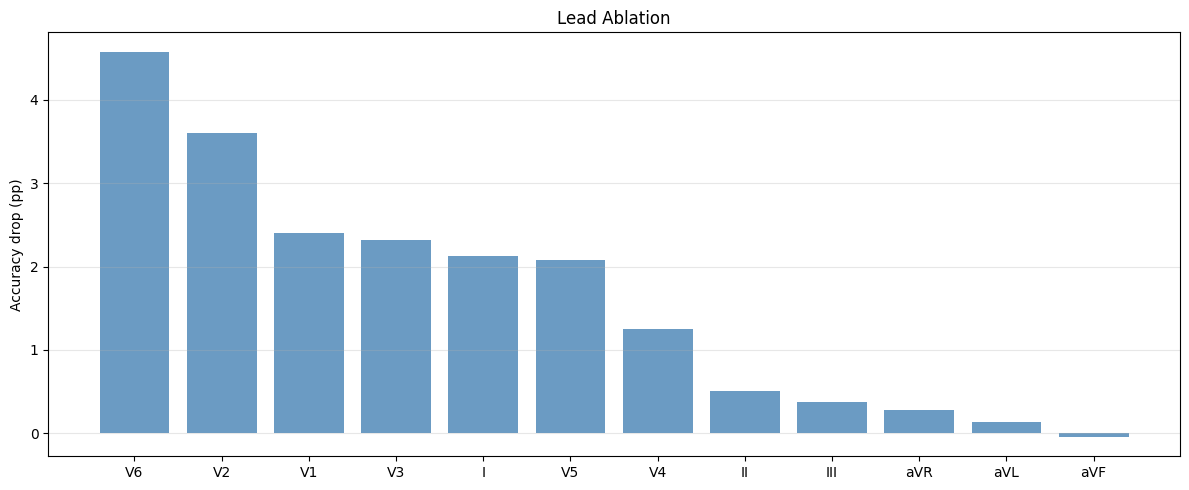

In [21]:
print('='*60)
print('E9: LEAD ABLATION')
print('='*60)
print(f'Baseline: {acc_base*100:.2f}%\n')

LEADS = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']
lead_drops = {}

for li in range(12):
    X_abl = X_te.copy()
    X_abl[:, :, li] = 0.0
    ds_abl = ECGDataset(X_abl, y_te, 'delta', N_BINS, threshold=0.1)
    ld_abl = DataLoader(ds_abl, BS, False)
    acc = _eval(model_base, ld_abl, device)
    drop = acc_base - acc
    lead_drops[LEADS[li]] = drop
    print(f'  Lead {LEADS[li]:>4} removed: {acc*100:.2f}% (drop: {drop*100:+.2f}pp)')

sr = sorted(lead_drops.items(), key=lambda x: x[1], reverse=True)
print(f'\nMost important: {sr[0][0]} (drop: {sr[0][1]*100:.2f}pp)')
print(f'Least important: {sr[-1][0]} (drop: {sr[-1][1]*100:.2f}pp)')

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
leads_sorted = [x[0] for x in sr]
drops_sorted = [x[1]*100 for x in sr]
ax.bar(leads_sorted, drops_sorted, color='steelblue', alpha=0.8)
ax.set_ylabel('Accuracy drop (pp)'); ax.set_title('Lead Ablation')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig(os.path.join(SAVE_DIR, 'ecg_lead_ablation.png'), dpi=150); plt.show()

## 16. Exp E10: Reduced-Lead Classification

Train on 1, 3, 6, and 12 leads. Tests whether RSNN works with
fewer leads — relevant for wearable devices (1-3 leads).

In [22]:
print('='*60)
print('E10: REDUCED-LEAD CLASSIFICATION')
print('='*60)

lead_configs = {
    '1-lead (II)': [1],
    '3-lead (I,II,III)': [0, 1, 2],
    '6-lead (limb)': [0, 1, 2, 3, 4, 5],
    '12-lead (all)': list(range(12)),
}

for name, lead_idx in lead_configs.items():
    print(f'\n--- {name} ---')
    n_leads = len(lead_idx)
    X_tr_sub = X_tr[:, :, lead_idx]
    X_va_sub = X_va[:, :, lead_idx]
    X_te_sub = X_te[:, :, lead_idx]

    ds_tr_sub = ECGDataset(X_tr_sub, y_tr, 'delta', N_BINS, threshold=0.1)
    ds_va_sub = ECGDataset(X_va_sub, y_va, 'delta', N_BINS, threshold=0.1)
    ds_te_sub = ECGDataset(X_te_sub, y_te, 'delta', N_BINS, threshold=0.1)
    ld_tr_sub = DataLoader(ds_tr_sub, BS, True, num_workers=2)
    ld_va_sub = DataLoader(ds_va_sub, BS, False, num_workers=2)
    ld_te_sub = DataLoader(ds_te_sub, BS, False, num_workers=2)

    inp_sz = ds_tr_sub.input_size
    # RSNN
    m_r = SNN(inp_sz, 256, N_CLASSES, 1, True, 20.0, 10.0, 10.0, True, 'max_over_time', 0.3)
    acc_r, _ = train_snn(m_r, ld_tr_sub, ld_va_sub, ld_te_sub, n_epochs=80, patience=15)

    # LSTM on direct input
    ds_tr_d2 = ECGDataset(X_tr_sub, y_tr, 'direct', N_BINS)
    ds_va_d2 = ECGDataset(X_va_sub, y_va, 'direct', N_BINS)
    ds_te_d2 = ECGDataset(X_te_sub, y_te, 'direct', N_BINS)
    ld_tr_d2 = DataLoader(ds_tr_d2, BS, True, num_workers=2)
    ld_va_d2 = DataLoader(ds_va_d2, BS, False, num_workers=2)
    ld_te_d2 = DataLoader(ds_te_d2, BS, False, num_workers=2)
    m_l = LSTMBaseline(n_leads, 128, 2, N_CLASSES, 0.3)
    acc_l, _ = train_baseline(m_l, ld_tr_d2, ld_va_d2, ld_te_d2)

    RESULTS[f'RSNN_{name}'] = acc_r
    RESULTS[f'LSTM_{name}'] = acc_l
    print(f'  RSNN: {acc_r*100:.2f}%, LSTM: {acc_l*100:.2f}%, gap: {(acc_r-acc_l)*100:+.2f}pp')

E10: REDUCED-LEAD CLASSIFICATION

--- 1-lead (II) ---


  Ep   0: loss=1.4319 tr=0.4251 va=0.4552 te=0.4547 *


  Ep  10: loss=1.3332 tr=0.4748 va=0.4682 te=0.4722 


  Ep  20: loss=1.3160 tr=0.4826 va=0.4821 te=0.4820 


## 17. Exp E11: Class-Wise Temporal Profile

Temporal analysis per superclass. Hypothesis: MI reaches peak
accuracy earlier than NORM.

In [ ]:
print('='*60)
print('E11: CLASS-WISE TEMPORAL')
print('='*60)

# Get predictions at every timestep, then filter by class
@torch.no_grad()
def classwise_temporal(model, loader, device, n_cls, is_lstm=False):
    model.eval()
    # Accumulate per-class correct counts at each timestep
    T_max = None
    class_correct = None
    class_total = np.zeros(n_cls)

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if is_lstm:
            seq = model.fc(model.forward_seq(x))
        else:
            _, _, seq = model(x)
        B, T, C = seq.shape
        if T_max is None:
            T_max = T
            class_correct = np.zeros((n_cls, T))

        rmax = torch.full((B, C), -float('inf'), device=device)
        for t in range(T):
            rmax = torch.max(rmax, seq[:, t])
            preds = rmax.argmax(1)
            for c in range(n_cls):
                mask = y == c
                if mask.sum() > 0:
                    class_correct[c, t] += (preds[mask] == c).float().sum().item()
        for c in range(n_cls):
            class_total[c] += (y == c).sum().item()

    # Normalise
    for c in range(n_cls):
        if class_total[c] > 0:
            class_correct[c] /= class_total[c]
    return class_correct

rsnn_cw = classwise_temporal(model_base, test_ld, device, N_CLASSES, False)
lstm_cw = classwise_temporal(model_lstm, test_ld_d, device, N_CLASSES, True)

time_ms = np.arange(N_BINS) * dt_ms
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ['steelblue', 'coral', 'green', 'purple', 'orange']
for c in range(N_CLASSES):
    axes[0].plot(time_ms, rsnn_cw[c]*100, lw=1.5, color=colors[c], label=SUPERCLASSES[c])
    axes[1].plot(time_ms, lstm_cw[c]*100, lw=1.5, color=colors[c], label=SUPERCLASSES[c])
axes[0].set_title('RSNN: Per-class temporal'); axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Accuracy (%)'); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[1].set_title('LSTM: Per-class temporal'); axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(SAVE_DIR, 'ecg_classwise.png'), dpi=150); plt.show()

## 18. Confusion Matrices

In [ ]:
@torch.no_grad()
def get_preds(model, loader, device, is_snn=True):
    model.eval()
    preds, labs = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if is_snn: logits, _, _ = model(x)
        else: logits = model(x)
        preds.append(logits.argmax(1).cpu()); labs.append(y.cpu())
    return torch.cat(preds).numpy(), torch.cat(labs).numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (model, loader, title, is_snn) in zip(axes, [
    (model_base, test_ld, 'RSNN', True),
    (model_lstm, test_ld_d, 'LSTM', False)]):
    p, l = get_preds(model, loader, device, is_snn)
    cm = confusion_matrix(l, p)
    ax.imshow(cm, cmap='Blues' if is_snn else 'Oranges')
    ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(SUPERCLASSES, rotation=45); ax.set_yticklabels(SUPERCLASSES)
    ax.set_title(f'{title} (F1={f1_score(l,p,average="weighted"):.3f})')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.savefig(os.path.join(SAVE_DIR, 'ecg_confusion.png'), dpi=150); plt.show()

## 19. Complete Results

In [ ]:
print('='*70)
print('ECG COMPLETE RESULTS')
print('='*70)
for k, v in sorted(RESULTS.items(), key=lambda x: x[1], reverse=True):
    print(f'  {k:30s} {v*100:7.2f}%')

print(f'\n--- Key findings ---')
print(f'Base RSNN: {acc_base*100:.2f}%')
print(f'LSTM: {acc_lstm*100:.2f}% | CNN: {acc_cnn*100:.2f}%')
print(f'Noise: RSNN retains {rsnn_noise[4]/rsnn_noise[0]*100:.1f}% at sigma=1.0, '
      f'LSTM retains {lstm_noise[4]/lstm_noise[0]*100:.1f}%')
print(f'Recurrence ablation: {acc_base*100:.2f}% -> {acc_abl*100:.2f}% '
      f'(drop {(acc_base-acc_abl)*100:.1f}pp)')
print(f'Spike efficiency: LSTM uses {lstm_ops/max(rsnn_ops,1):.1f}x more ops')

with open(os.path.join(SAVE_DIR, 'ecg_extended_results.json'), 'w') as f:
    json.dump(RESULTS, f, indent=2, default=str)
print('\nSaved ecg_extended_results.json')